In this section, you will learn how to:

- work with `DataGraph` objects to represent problem data,
- create, inspect, draw, and construct graphs in different ways,
- use coordinates, distances, weights, and unit-disk graph properties,

---

## Standard structure for Graphs

Working with graphs is an essential part of computations with the Rydberg analog model. For that reason, QoolQit implements a specific `DataGraph` class to serve as the basis of all graph creation and manipulation, and setting the logic related to unit-disk graphs. QoolQit integrates with [NetworkX](https://networkx.org/) for many operations, and the `DataGraph` inherits from `nx.Graph`.

### Basic construction

The `DataGraph` is an undirected graph with no self loops. The default way to instantiate a `DataGraph` is with a set of edges.

In [167]:
from qoolqit import DataGraph

edges = [(0, 1), (1, 2), (2, 3), (3, 0)]
graph = DataGraph(edges)

Later in the [graph constructors](#graph-constructors) section we also describe how to construct graphs from sets of coordinates, or with built-in constructors.

As with any NetworkX graph, the set of nodes and edges can be accessed:

In [168]:
graph.nodes, graph.edges

(NodeView((0, 1, 2, 3)), EdgeView([(0, 1), (0, 3), (1, 2), (2, 3)]))

These are the standard `NodeView` and `EdgeView` objects from NetworkX, and thus can be used add and access node and edge attributes.

### Drawing

We can draw the graph with `graph.draw()`, which calls [`draw_networkx`](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx.html). As such, optional arguments can be passed that will be fed to NetworkX.

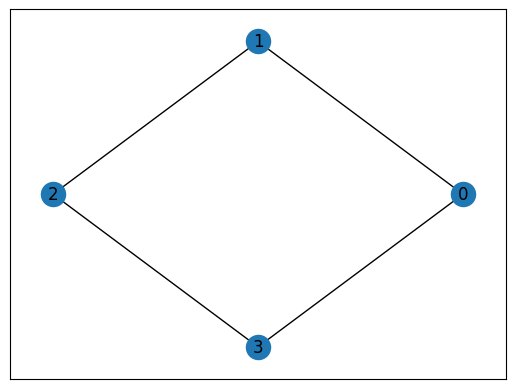

In [169]:
import networkx as nx

pos = nx.circular_layout(graph)
graph.draw(pos=pos)

### Coordinates and distances

One convenient property added by QoolQit is the `sorted_edges`, which guarantees that the indices in each edge tuple are always provided as $(u, v):u<v$. This condition is not guaranteed by calling the NetworkX property `graph.edges`, but is sometimes useful.

In [170]:
graph.sorted_edges

{(0, 1), (0, 3), (1, 2), (2, 3)}

Another convenient property is accessing the pairs of all nodes in the graph, which again follow the convention of $(u, v):u<v$.

In [171]:
graph.all_node_pairs

{(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)}

In QoolQit a set of attributes that takes center stage when dealing with graphs are the **node coordinates**. These are essential for the Rydberg analog model as they directly translate to qubit positions that define the interaction term in the Hamiltonian. This behaviour has a close connection with the study of unit-disk graphs, where node coordinates are also essential. The coordinates can be set directly in the respective property:

In [172]:
# The list must have the same length as the number of nodes:
graph.coords = [(-0.5, -0.5), (-0.5, 0.5), (0.5, 0.5), (0.5, -0.5)]
graph.coords

{0: (-0.5, -0.5), 1: (-0.5, 0.5), 2: (0.5, 0.5), 3: (0.5, -0.5)}

Both a dictionary or a list can be passed, which will be converted to a dictionary. 
Because the graph now has a set of node coordinates, we can directly access the distance between the nodes. 
Optionally, a set of node pairs can be given and only those distances will be computed.

In [173]:
# Compute for all node pairs
graph.distances()
print(graph.distances())

# Compute only for connected nodes
graph.distances(graph.sorted_edges)
print(graph.distances(graph.sorted_edges))

# Compute for a specific set of node pairs
graph.distances([(0, 1), (0, 2)])
print(graph.distances([(0, 1), (0, 2)]))

{(0, 1): 1.0, (1, 2): 1.0, (0, 3): 1.0, (2, 3): 1.0, (0, 2): 1.4142135623730951, (1, 3): 1.4142135623730951}
{(0, 1): 1.0, (1, 2): 1.0, (0, 3): 1.0, (2, 3): 1.0}
{(0, 1): 1.0, (0, 2): 1.4142135623730951}


Furthermore, when calling `graph.draw()` the coordinate information will be automatically used.

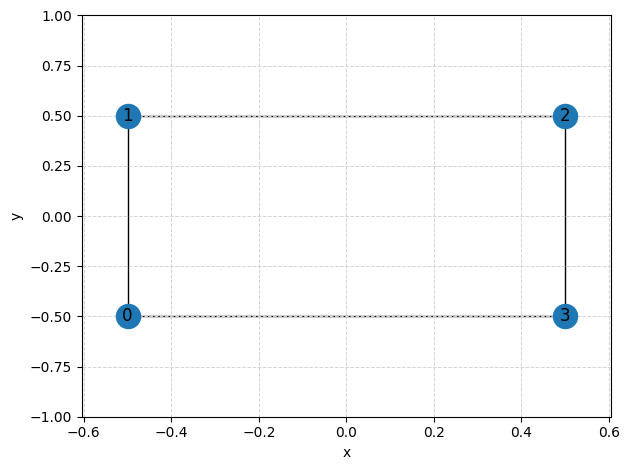

In [174]:
graph.draw()

Graph coordinates can be rescaled. The `rescale_coords` method only accepts a keyword argument,
which must be either `scaling` or `spacing`.

In [175]:
# Rescale coordinates by a constant factor
graph.rescale_coords(scaling = 2.0)

# Rescale coordinates by setting the minimum spacing
graph.rescale_coords(spacing = 1.0)

The minimum and maximum distance can be directly checked.

In [176]:
# Compute for all node pairs
graph.min_distance()
graph.max_distance()

# Compute only for connected nodes
graph.min_distance(connected = True)

# Compute only for disconnected nodes
graph.min_distance(connected = False)

1.4142135623730951

### Node and edge weights

Two important attributes are **node weights** and **edge weights**:

In [177]:
import random

graph.node_weights = {i: random.random() for i in graph.nodes}
graph.edge_weights = {edge: random.random() for edge in graph.sorted_edges}

If the graph does not have these attributes, the dictionaries will still be returned with `None` in place of the value.
A set of boolean properties allows quickly checking if the graph has coordinates or weights. It only returns `True` if there is a value set for every node / edge in the graph.

!!! note
    Accessing weights as NumPy arrays or Torch tensors will be designed later.

In [178]:
assert graph.has_coords
assert graph.has_node_weights
assert graph.has_edge_weights

## Graph constructors

Class constructors can help you create a variety of graphs. A useful constructor is starting from a set of coordinates. By default, it will create an empty set of edges, but we can use the `set_ud_edges` method to specify the edges as the unit-disk intersections.

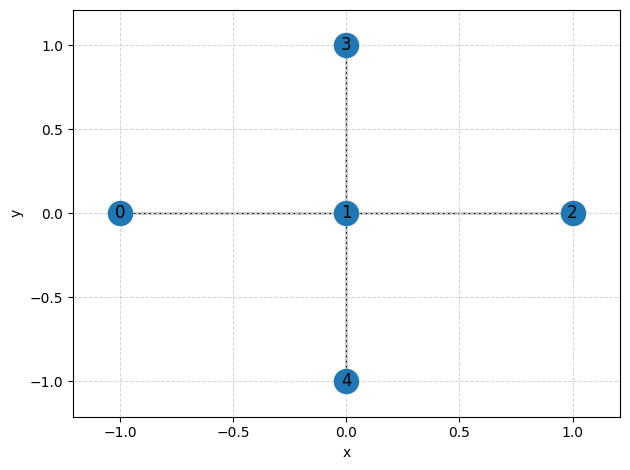

In [179]:
from qoolqit import DataGraph

coords = [(-1.0, 0.0), (0.0, 0.0), (1.0, 0.0), (0.0, 1.0), (0.0, -1.0)]

graph = DataGraph.from_coordinates(coords)

assert len(graph.edges) == 0

graph.set_ud_edges(radius = 1.0)

assert len(graph.edges) > 0

graph.draw()

Some geometric graph constructors will already have coordinates by default.

### Line
A line graph on n nodes.

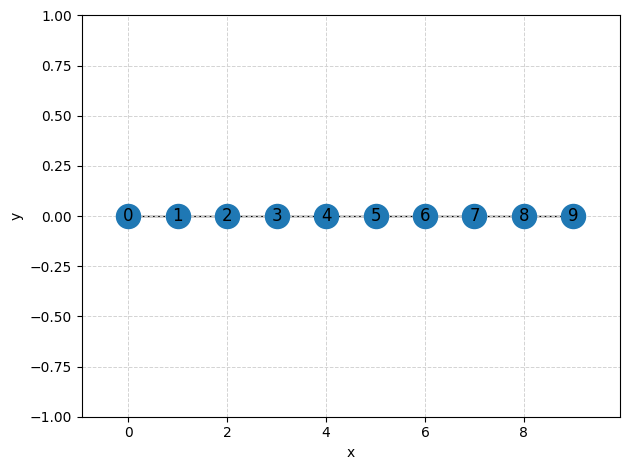

In [180]:
graph = DataGraph.line(n = 10, spacing = 1.0)
graph.draw()

### Circle
A circle graph on n nodes.

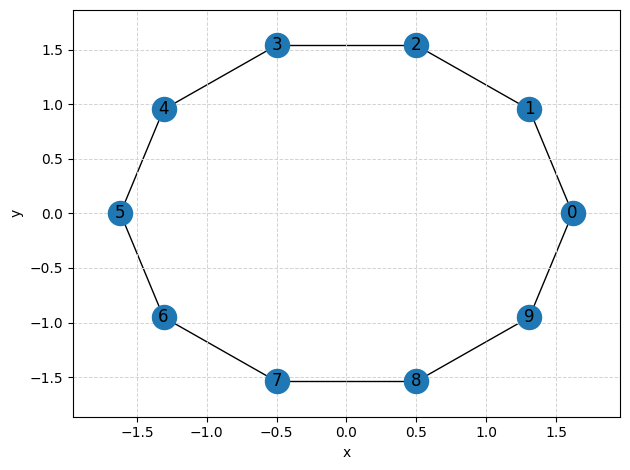

In [181]:
graph = DataGraph.circle(n = 10, spacing = 1.0, center = (0.0, 0.0))
graph.draw()

### Triangular
A triangular lattice graph with m rows and n columns of triangles.

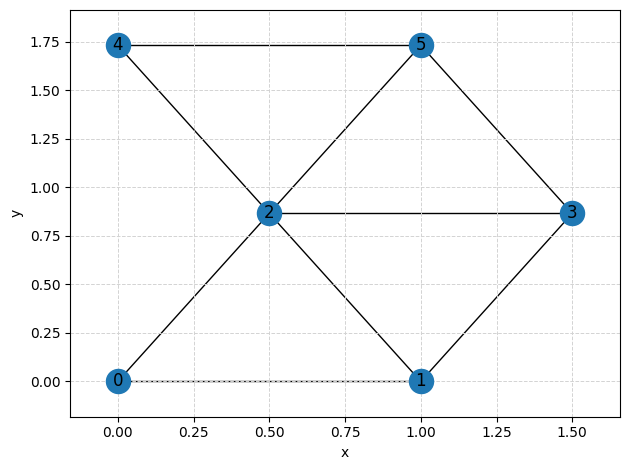

In [182]:
graph = DataGraph.triangular(m = 2, n = 2, spacing = 1.0)
graph.draw()

### Square
A square lattice graph with m rows and n columns of square.

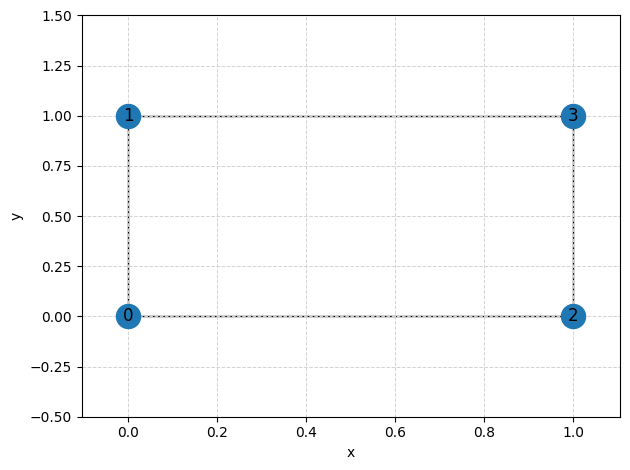

In [183]:
graph = DataGraph.square(m = 2, n = 2, spacing = 1.0)
graph.draw()

### Hexagonal
A Hexagonal lattice graph with m rows and n columns of hexagons.

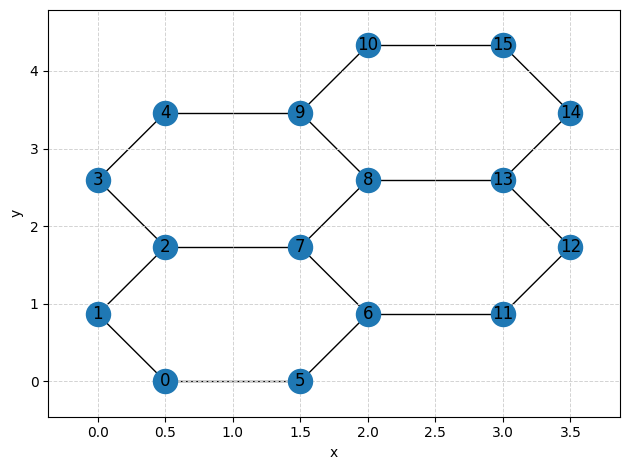

In [184]:
graph = DataGraph.hexagonal(m = 2, n = 2, spacing = 1.0)
graph.draw()

### Heavy-hexagonal
An Heavy-Hexagonal lattice graph with m rows and n columns of hexagons where each edge is decorated with an additional lattice site.

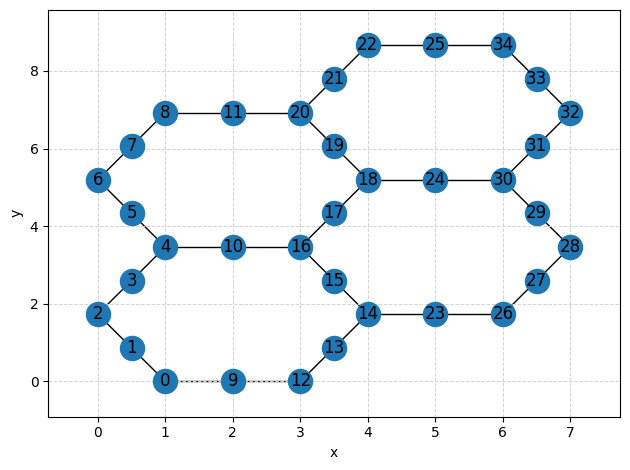

In [185]:
graph = DataGraph.heavy_hexagonal(m = 2, n = 2, spacing = 1.0)
graph.draw()

### Random unit-disk
A random unit-disk graph by uniformly sampling points in area of side L.

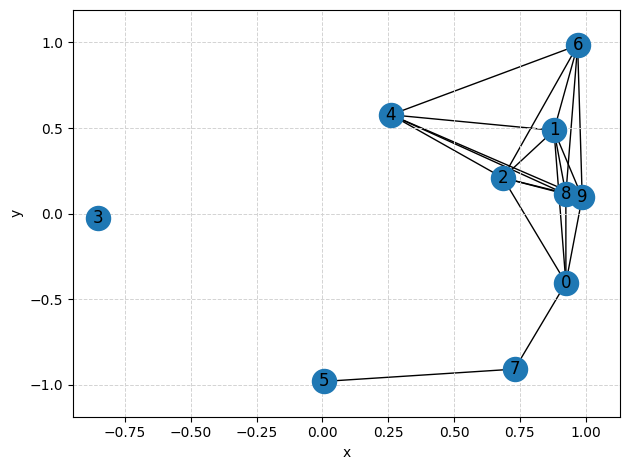

In [186]:
graph = DataGraph.random_ud(n = 10, radius = 1.0, L = 2.0)
graph.draw()

Other generic constructors are also available which have no information on node coordinates.

### Erdős–Rényi
A random Erdős–Rényi graph of n nodes.

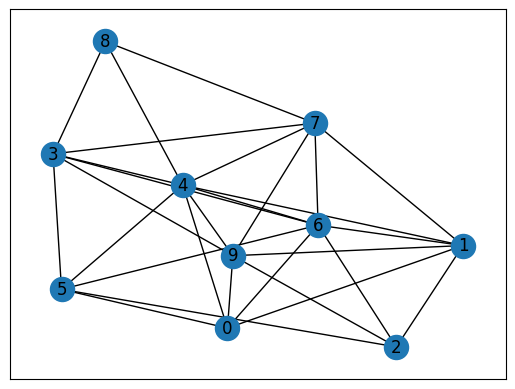

In [187]:
graph = DataGraph.random_er(n = 10, p = 0.5, seed = 1)
graph.draw()

## Loading from a matrix

Loading an adjacency matrix into a graph is also possible.

- Given that graphs in QoolQit are undirected, the matrix must be symmetric.
- As in the standard adjacency matrix interpretation, off-diagonal elements are loaded as edge-weights as long as they are non-zero.
- Given that QoolQit does not consider graphs with self-loops, diagonal elements are loaded as node-weights.

In [188]:
import numpy as np

n_nodes = 5
data = np.random.rand(n_nodes, n_nodes)

# Matrix must be symmetric
data = data + data.T

graph = DataGraph.from_matrix(data)

assert graph.has_node_weights
assert graph.has_edge_weights

If all values in the diagonal are 0, then no node-weights will be set. Furthermore, edges and edge-weights will only be set for non-zero off-diagonal elements.

In [189]:
# Setting the diagonal to zero
np.fill_diagonal(data, 0.0)

# Removing the value for the pair (1, 2)
data[1, 2] = 0.0
data[2, 1] = 0.0

graph = DataGraph.from_matrix(data)

# Checking there are no node weights and the edge (1, 2) was not added
assert not graph.has_node_weights
assert (1, 2) not in graph.edges